# Système de recommandation agricole - Exploration des données + Fusion

Ce notebook a pour but d'appréhender les différents documents CSV de l'entreprise.

### Libraires nécessaires

In [2]:
# Imports de base
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
# Imports sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Chargement des données provenant du dossier "Agriculture CropYield Dataset"
### On retrouve uniquement le fichier crop_yield.csv

In [3]:
data_crop_yield = pd.read_csv("../data/raw/crop_yield.csv")

### Ce que nous avons dans le fichier.

In [4]:
data_crop_yield.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [5]:
data_crop_yield.shape

(1000000, 10)

**Agriculture CropYield Dataset (crop_yield.csv) est un jeu de données volumineux contenant des relevés granulaires (Il ressemble à des données synthétiques)** :
- Nous avons 10 colonnes pour 1 million de lignes. 
- Nous avons un détail de plusieurs informations par **grande région**, par type de **sol** et de **récolte**.
- On retrouve un détail des températures (en celsius), les types de fertilisant utilisé, d'irrigation utilsé, les conditions météos, le nombre de jour de récolte et le rendement en tonnes par hectare.

### Génération des statistiques descriptives

In [6]:
data_crop_yield.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


**On retouve 4 variables numériques** :
- On retrouve bien nos 1M de lignes.
- Pas d'alerte particulière sur Rainfall_mm / Temperature_Celsius / Days_to_Harvest.
- On voit des rendements négatifs dans le minimum pour Yield_tons_per_hectare - à analyser.

### Nombre de valeurs par variable

In [7]:
data_crop_yield.columns

Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='object')

In [8]:
cols = ['Soil_Type','Crop','Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition']
for col in cols:
    print(f"Nombre de valeur unique : {col}: {data_crop_yield[col].nunique()}")

Nombre de valeur unique : Soil_Type: 6
Nombre de valeur unique : Crop: 6
Nombre de valeur unique : Fertilizer_Used: 2
Nombre de valeur unique : Irrigation_Used: 2
Nombre de valeur unique : Weather_Condition: 3


#### Analyse de Yield_tons_per_hectare

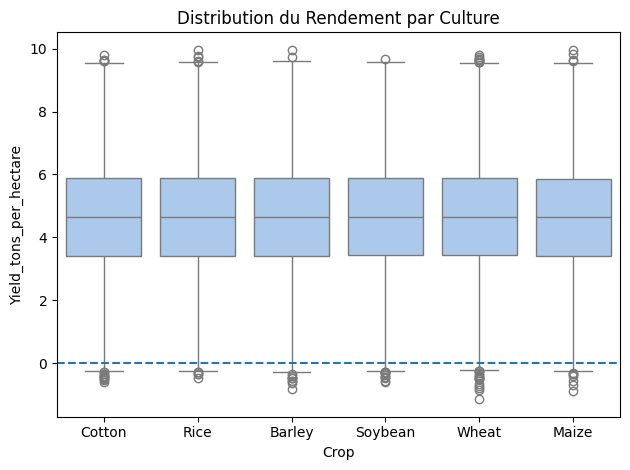

In [9]:
plt.figure()
sns.boxplot(data=data_crop_yield, x="Crop", y="Yield_tons_per_hectare", color="#a1c9f4")
plt.title("Distribution du Rendement par Culture")
# Ligne horizontale à y = 0
plt.axhline(y=0, linestyle='--')
plt.tight_layout()
plt.savefig('../notebooks/graph/boxplot_crop_yield.png')

**Analyse du boxplot** :
- Nous avons croisé le rendement agricole avec le type de récolte pour identifier des valeurs aberrantes.
- Pour l'ensemble des types de récolte nous avons des valeurs négatives, ce qui est un non sens, il n'est pas logique d'avoir un rendement négatif.
- Certaines valeurs à l'inverse présentent des points très hauts (proches de 10 t/ha), bien que rare, ce n'est pas impossible si les conditions étaient parfaites.


### Valeurs manquantes & valeurs en doublons

In [10]:
# Analyse des valeurs manquantes
print(f"Valeurs manquantes :\n{data_crop_yield.isnull().mean()}")
print("-"*8)
print(f"Valeurs en doublons :\n{data_crop_yield.duplicated(keep=False).any()}")

Valeurs manquantes :
Region                    0.0
Soil_Type                 0.0
Crop                      0.0
Rainfall_mm               0.0
Temperature_Celsius       0.0
Fertilizer_Used           0.0
Irrigation_Used           0.0
Weather_Condition         0.0
Days_to_Harvest           0.0
Yield_tons_per_hectare    0.0
dtype: float64
--------
Valeurs en doublons :
False


- Pas de valeurs manquantes identifiées
- Pas de doublons identifiés

### Distribution de notre variable cible

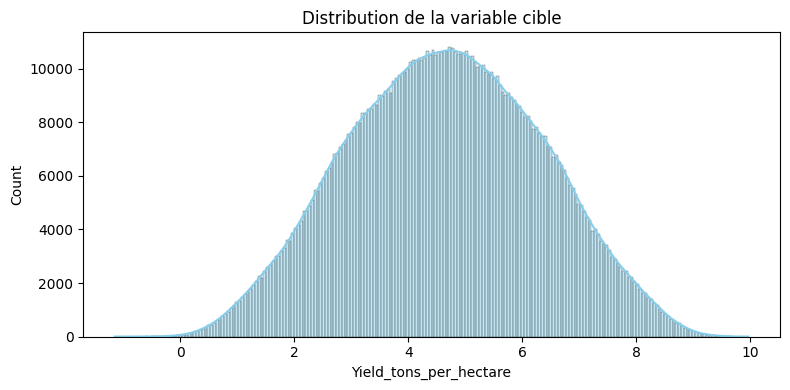

In [11]:
fig = plt.figure(figsize=(8, 4))

# Histogramme + KDE
sns.histplot(data_crop_yield['Yield_tons_per_hectare'], kde=True, color="skyblue")
plt.title('Distribution de la variable cible')
plt.tight_layout()
plt.savefig('../notebooks/graph/distribution_variable_cible.png')
plt.show()

- Notre distribution ressemble à une cloche, donc à une distribution normale même si on ne peut pas la considérer comme telle car on voit quelques petits dépassements.


### Relation entre notre variable cible et les précipitations

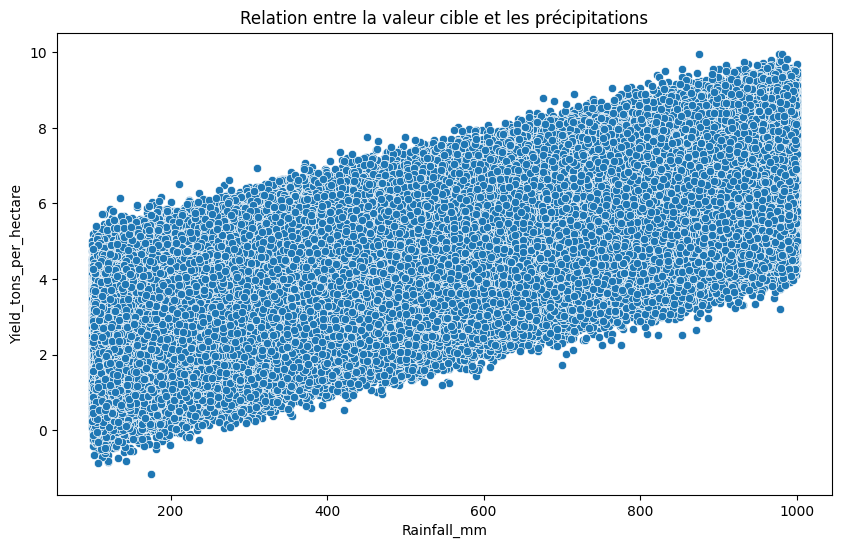

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data_crop_yield['Rainfall_mm'], y = data_crop_yield['Yield_tons_per_hectare'])
plt.title("Relation entre la valeur cible et les précipitations")
plt.show()

- On voit un rendement croissant entre beaucoup de pluie et un gros rendement, ce qui a un sens d'un point de vue agricole.

### Matrice de corrélation avec la méthode Pearson.

In [13]:
cols_num = ['Temperature_Celsius','Rainfall_mm','Days_to_Harvest','Yield_tons_per_hectare']
pearson_corr = data_crop_yield[cols_num].corr(numeric_only=True, method='pearson')
pearson_corr

,Temperature_Celsius,Rainfall_mm,Days_to_Harvest,Yield_tons_per_hectare
Temperature_Celsius,1.000000,-0.000123,-0.000731,0.085565
Rainfall_mm,-0.000123,1.000000,-0.002669,0.764618
Days_to_Harvest,-0.000731,-0.002669,1.000000,-0.002591
Yield_tons_per_hectare,0.085565,0.764618,-0.002591,1.000000


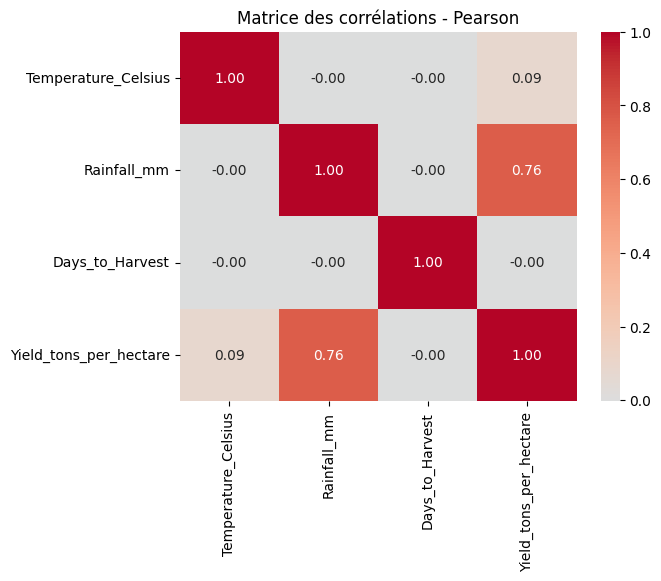

In [14]:
# Matrice des corrélations
sns.heatmap(pearson_corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Matrice des corrélations - Pearson')
plt.show()

- Ici on peut noter une seule forte relation, qui est bien entre la pluie et le rendement.

### Suppression des valeurs de rendement négatif
- Les valeurs extrêmes supérieurs ne sont pas des aberrations alors que les rendements négatifs si, alors on décide de les supprimer.

In [15]:
data_crop_yield_suppr = data_crop_yield.loc[data_crop_yield['Yield_tons_per_hectare']<0]
data_crop_yield_suppr.count()

Region                    231
Soil_Type                 231
Crop                      231
Rainfall_mm               231
Temperature_Celsius       231
Fertilizer_Used           231
Irrigation_Used           231
Weather_Condition         231
Days_to_Harvest           231
Yield_tons_per_hectare    231
dtype: int64

- On ne compte que 231 lignes en négatif. Sur 1M de lignes, on peut les supprimer.

In [16]:
data_crop_yield = data_crop_yield[data_crop_yield['Yield_tons_per_hectare'] >= 0]

### Sauvegarde du fichier sans les valeurs extrêmes

In [17]:
data_crop_yield.to_csv("../data/processed/crop_yield.csv")
data_crop_yield.shape

(999769, 10)

### Transformation des colonnes Fertilizer_Used et Irrigation_Used en numérique pour l'ACP

In [18]:
data_crop_yield['Fertilizer_Used'] = data_crop_yield['Fertilizer_Used'].astype(int)
data_crop_yield['Irrigation_Used'] = data_crop_yield['Irrigation_Used'].astype(int)

In [19]:
data_crop_yield.shape

(999769, 10)

- On passe d'1 M de lignes à 999 769 lignes.

## Passons à l'ACP du fichier crop_yield
- L’ACP (Analyse en Composantes Principales) est une méthode statistique utilisée pour simplifier et analyser des données complexes.
- L’objectif de l’ACP est de réduire la dimension des données tout en conservant le maximum d’information (variance).

In [20]:
# Chargement des données
df = data_crop_yield

# Séparation des variables explicatives et de la variable cible
print("Colonnes :", df.columns.tolist())
print("================")
# Variable Cible
target_col = "Yield_tons_per_hectare"

# Variables explicatives numériques pour l'ACP
numeric_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Days_to_Harvest"
]
# Nettoyage et vérification des doublons déjà effectué
# Matrice X pour l'ACP / Scaling
df_pca = df
X = df_pca[numeric_features].copy()

# Standardisation obligatoire avant ACP
# Uniquement sur les variables explicatives
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Moyennes après scaling :", X_scaled.mean(axis=0))
print("================")
print("Std après scaling :", X_scaled.std(axis=0))

Colonnes : ['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']
Moyennes après scaling : [ 2.40616931e-16  3.22035515e-16  8.55122553e-17 -4.35521194e-17
 -1.41913956e-16]
Std après scaling : [1. 1. 1. 1. 1.]


In [21]:
# ACP complète
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
explained_variance = pca.explained_variance_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Tableau récapitulatif
pca_summary = pd.DataFrame({
    "Composante": [f"PC{i+1}" for i in range(len(explained_variance_ratio))],
    "Variance expliquée": explained_variance_ratio,
    "Variance expliquée cumulée": cumulative_variance,
    "Valeur propre": explained_variance
})

print("\nRésumé ACP :")
print(pca_summary)


Résumé ACP :
  Composante  Variance expliquée  Variance expliquée cumulée  Valeur propre
0        PC1            0.200634                    0.200634       1.003173
1        PC2            0.200543                    0.401177       1.002716
2        PC3            0.200154                    0.601331       1.000769
3        PC4            0.199424                    0.800755       0.997120
4        PC5            0.199245                    1.000000       0.996227


- Ici l'ACP n'apporte pas de vraie réduction de dimension car elle est répartie sur l'ensemble des 5 composantes principales.
- Nous avons des variables indépendantes ou faiblement liées

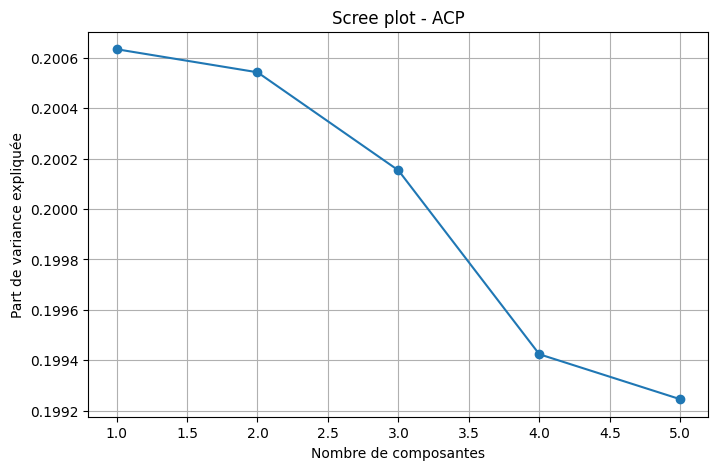

In [22]:
# Scree plot (variance expliquée)
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o"
)
plt.xlabel("Nombre de composantes")
plt.ylabel("Part de variance expliquée")
plt.title("Scree plot - ACP")
plt.grid(True)
plt.show()

In [23]:
# Intéressons nous maintenant à nos composantes. La formule de ce calcul nous est donnée par l'attribut components_ (cours OC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_features,
    columns=[f"PC{i+1}" for i in range(len(numeric_features))]
)

print("\nLoadings :")
print(loadings)


Loadings :
                          PC1       PC2       PC3       PC4       PC5
Rainfall_mm         -0.246778  0.710124 -0.129844  0.051049  0.644484
Temperature_Celsius  0.500985  0.033802 -0.610713 -0.607091  0.079634
Fertilizer_Used      0.693791 -0.068857 -0.052776  0.658352  0.278747
Irrigation_Used      0.360248  0.033606  0.770179 -0.437482  0.290733
Days_to_Harvest     -0.277472 -0.699078 -0.119202 -0.063374  0.645037


**Même si l’ACP ne réduit pas beaucoup la dimension, elle reste très utile pour comprendre les relations.**

- PC1 :
    - conditions/intensité de croissance plus fortes” vs “cycle plus long
- PC2 :
    - PC2 est surtout un axe lié à la pluie, opposé à un bloc de variables agricoles/cycle
- PC3 :
    - irrigation vs température
- PC4 :
    - fertilisation et autres conditions de croissance
- PC5 : 
    - cycle plus long et environnement plus humide

<Axes: >

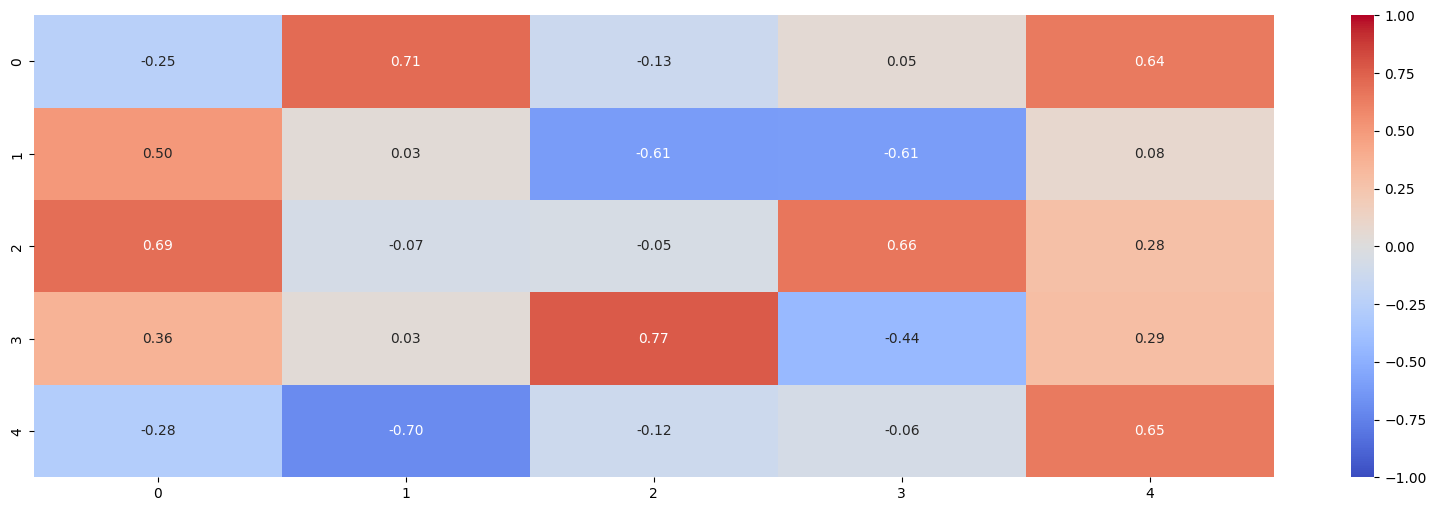

In [24]:
# Représentation plus visuelle
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pca.components_.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

        PC1       PC2     Crop  Yield_tons_per_hectare
0 -0.838228  0.580242   Cotton                6.555816
1 -0.403501  0.173794     Rice                8.527341
2 -0.529254 -1.093545   Barley                1.127443
3 -1.945599  0.127551  Soybean                6.517573
4  1.109618  0.328584    Wheat                7.248251


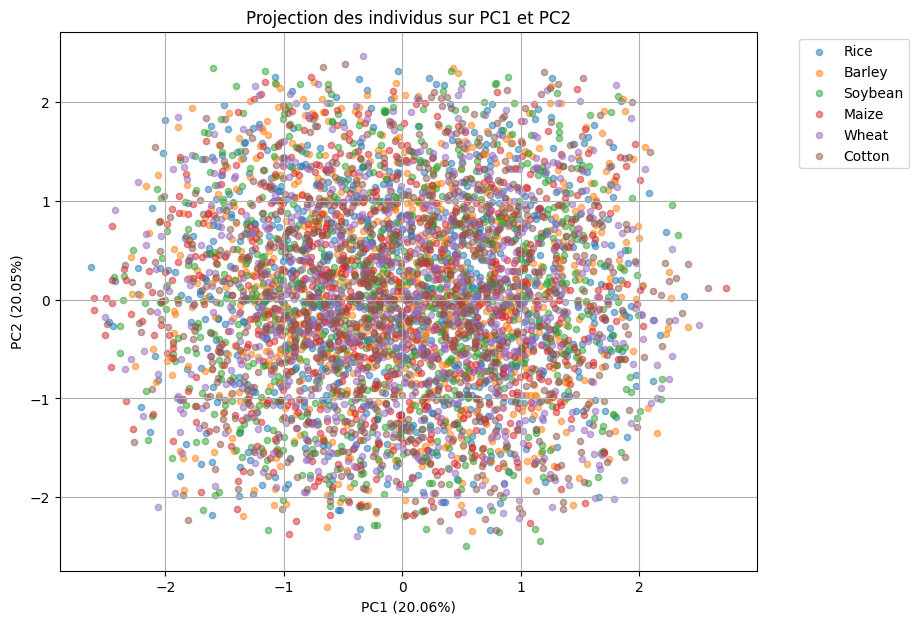

In [25]:
# Projection des individus
# Coordonnées des individus
scores = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)
scores["Crop"] = df_pca["Crop"].values
scores[target_col] = df_pca[target_col].values
print(scores.head())

# Pour éviter un graphe illisible sur 1M de lignes, on échantillonne
sample_size = min(5000, len(scores))
scores_sample = scores.sample(sample_size, random_state=42)

plt.figure(figsize=(9, 7))
for crop_name in scores_sample["Crop"].dropna().unique()[:10]:
    subset = scores_sample[scores_sample["Crop"] == crop_name]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.5, label=crop_name, s=20)

plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.2%})")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.2%})")
plt.title("Projection des individus sur PC1 et PC2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

- Il n’y a aucune séparation claire entre les cultures dans les 2 premières composantes
- Variables peu corrélées
- Pas de clusters naturels

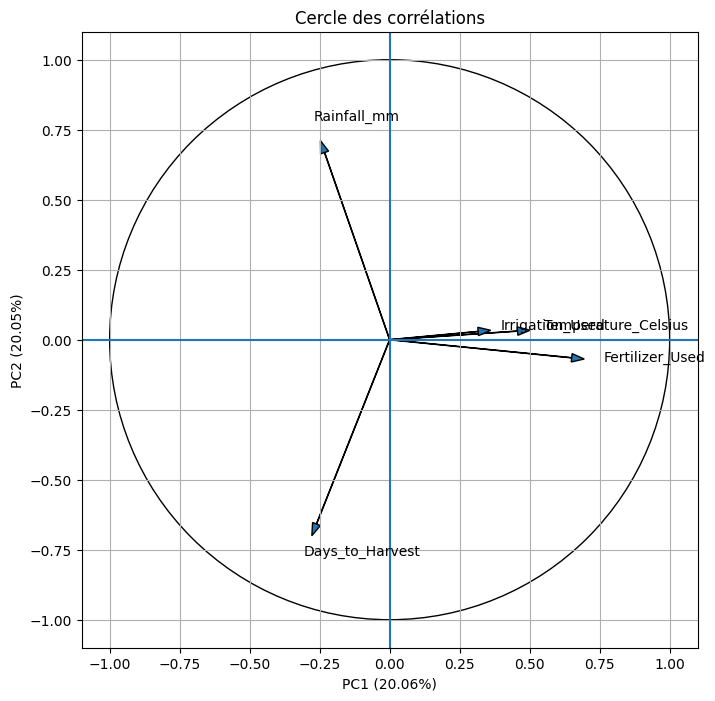

In [26]:
# Cercle des corrélations
correlation_circle = loadings.iloc[:, :2].copy()
correlation_circle["PC1"] = correlation_circle["PC1"] * np.sqrt(pca.explained_variance_[0])
correlation_circle["PC2"] = correlation_circle["PC2"] * np.sqrt(pca.explained_variance_[1])

plt.figure(figsize=(8, 8))

# Cercle unité
circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

for var in correlation_circle.index:
    x = correlation_circle.loc[var, "PC1"]
    y = correlation_circle.loc[var, "PC2"]
    plt.arrow(0, 0, x, y, head_width=0.03, length_includes_head=True)
    plt.text(x * 1.1, y * 1.1, var, fontsize=10)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.axhline(0)
plt.axvline(0)
plt.xlabel(f"PC1 ({explained_variance_ratio[0]:.2%})")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]:.2%})")
plt.title("Cercle des corrélations")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.savefig('../notebooks/graph/cercle_correlation.png')
plt.show()


- Les variables alignées, elles pointent dans la même direction :
    - Fertilizer_Used
    - Temperature_Celsius
    - Irrigation_Used
    - Ces variables sont positivement corrélées entre elles
- Variable opposée : Days_to_Harvest est négativement correlé avec celles du dessus
    - plus d’engrais / température / irrigation = moins de jours jusqu’à récolte
- Variable isolée :
    - Rainfall : Rainfall est faiblement corrélée aux autres variables

- 3 dimensions réelles : intensité agricole / durée de culture / conditions climatiques

### Proxy
Un proxy est une variable qui remplace quelque chose qu'il ne peut pas être mesuré directement.

Variable, proxy de :
- Rainfall_mm : disponibilité en eau
- Irrigation_Used : gestion de l’eau
- Fertilizer_Used : fertilité du sol
- Temperature_Celsius : conditions climatiques
- pesticides_tonnes : intensité agricole

Les variables utilisées dans le modèle sont des proxies permettant d’approcher des phénomènes agronomiques complexes, tels que la disponibilité en eau ou la fertilité du sol.


# Dans un premier temps analyse de chaque fichier puis à la fin de ce notebook, nettoyage et fusion des données
- L'idée est de comprendre de manière globale ce que nous avons dans chaque fichier du dossier prédictions et ensuite passer à la fusion et à l'enrichissement.

## Chargement des données provenant du fichier "pesticides"

In [27]:
data_pesticides = pd.read_csv("../data/raw/pesticides.csv")

In [28]:
data_pesticides.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


### Informations du dataset

In [29]:
data_pesticides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Domain   4349 non-null   object 
 1   Area     4349 non-null   object 
 2   Element  4349 non-null   object 
 3   Item     4349 non-null   object 
 4   Year     4349 non-null   int64  
 5   Unit     4349 non-null   object 
 6   Value    4349 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 238.0+ KB


In [30]:
data_pesticides.shape

(4349, 7)

Ici nous avons les informations concernant **l'utilisation de pesticide**. On a
- 5 variables non numériques
- 2 variables numériques
- La variable principale ici va être "Value" qui est la valeur en tonne de l'utilisation de pesticide

Le jeu se compose de 7 colonnes et 4349 lignes

### Génération des statistiques descriptives

In [31]:
data_pesticides.describe()

,Year,Value
count,4349.000000,4.349000e+03
mean,2003.138883,2.030334e+04
std,7.728044,1.177362e+05
min,1990.000000,0.000000e+00
25%,1996.000000,9.300000e+01
50%,2003.000000,1.137560e+03
75%,2010.000000,7.869000e+03
max,2016.000000,1.807000e+06


- A première vue nous ne voyons pas d'aberration statistique

#### Valeurs manquantes & doublons

In [33]:
print(f"Valeurs manquantes :\n{data_pesticides.isnull().mean()}")
print("-"*8)
print(f"Valeurs en doublons :\n{data_pesticides.duplicated(keep=False).any()}")
print(f"Valeurs en doublons sur les variables non-num clés :\n{data_pesticides.duplicated(['Area','Year']).any()}")

Valeurs manquantes :
Domain     0.0
Area       0.0
Element    0.0
Item       0.0
Year       0.0
Unit       0.0
Value      0.0
dtype: float64
--------
Valeurs en doublons :
False
Valeurs en doublons sur les variables non-num clés :
False


- Pas de présence de valeurs manquantes ou de doublons

### Distibution de l'utilisation en tonne de pesticide

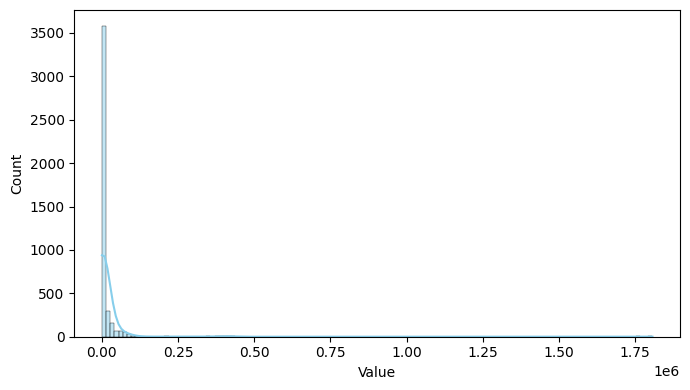

In [34]:
plt.figure(figsize=(7, 4))
# Histogramme + KDE
sns.histplot(data_pesticides['Value'], kde=True, color="skyblue")
plt.tight_layout()
plt.show()

- La distibution est étalée sur la gauche (pas dans le cadre d'une distribution normale), avec une importante concentration entre 0 et 0,1

### Relation entre la valeur en tonne des pesticides et l'année

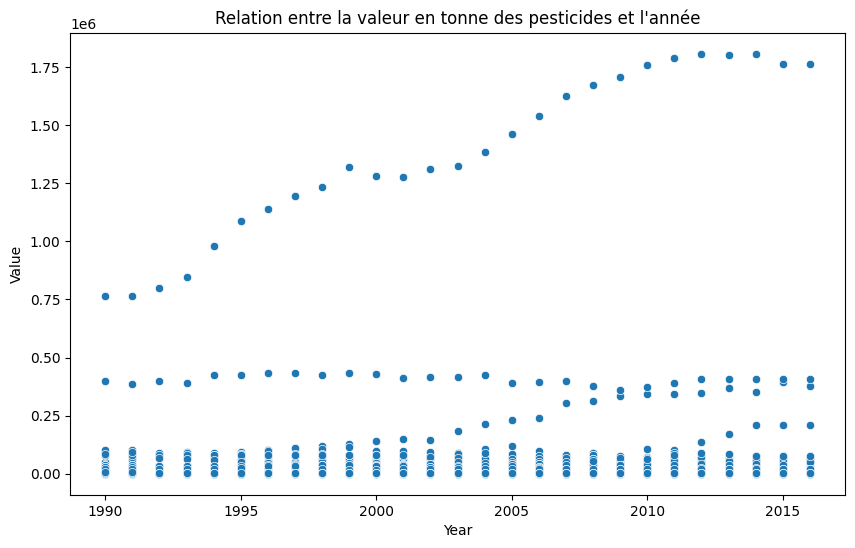

In [35]:
plt.figure(figsize=(10, 6))
# Scatter plot
sns.scatterplot(x=data_pesticides['Year'], y = data_pesticides['Value'])
plt.title("Relation entre la valeur en tonne des pesticides et l'année")
plt.show()

- Relation non linéaire
- On voit une concentration de l'utilisation de pestice évoluer de manière stable à travers le temps
- Cependant on remarque une augmentation croissante pour certaines valeurs (mais une minorité)
- On peut penser que les valeurs extrêmes sont des gros utilisateurs de pesticide et pas des valeurs aberrantes

### Valeurs extrêmes

In [36]:
# Nombre de tonnes total (sur l'ensemble des années)
print(f"Nombre de tonnes au global : {data_pesticides['Value'].sum()}")
top5_pays = (
    data_pesticides
    .groupby('Area')['Value']
    .sum()
    .nlargest(5)
)
# Nombre de tonnes sur le top5 en utilisant le plus (sur l'ensemble des années)
top5 = top5_pays.sum()
print(f"Nombre de tonnes du top 5 : {top5}")
print(f"% du top 5 sur le total : {round((top5/(data_pesticides['Value'].sum())*100),2)}%")
print(f"Détails du nombre de tonnes du top 5 : {top5_pays}")


Nombre de tonnes au global : 88299232.03
Nombre de tonnes du top 5 : 58343148.35
% du top 5 sur le total : 66.07%
Détails du nombre de tonnes du top 5 : Area
China, mainland             37194836.00
United States of America    10978289.10
Brazil                       5671552.00
Argentina                    2250064.53
France                       2248406.72
Name: Value, dtype: float64


- **Sur l'ensemble des années, le top 5 représente plus de 66% de la totalité d'utilisation des pesticides.**

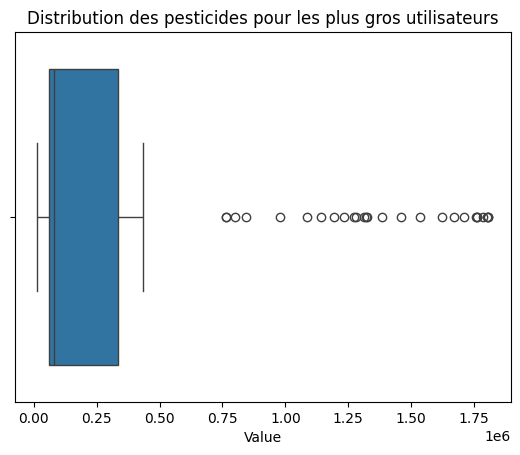

In [37]:
# Visualisation par pays (top 10)
top_pesticides = data_pesticides.groupby('Area')['Value'].mean().sort_values(ascending=False).head(10)
sns.boxplot(x='Value', data=data_pesticides[data_pesticides['Area'].isin(top_pesticides.index)])
plt.title("Distribution des pesticides pour les plus gros utilisateurs")
plt.show()

In [38]:
# Calcul de l'IQR
Q1 = data_pesticides['Value'].quantile(0.25)
Q3 = data_pesticides['Value'].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_pesticides[data_pesticides['Value'] > upper_bound]
print(f"Nombre d'outliers détectés : {len(outliers)}")

Nombre d'outliers détectés : 615


In [39]:
# On isole les lignes qui dépassent la borne haute 
outliers_df = data_pesticides[data_pesticides['Value'] > upper_bound]

# On regarde quels sont les pays les plus fréquents dans ces outliers
outliers_by_country = outliers_df.groupby('Area').size().sort_values(ascending=False)

# On affiche le top 10 des pays "outliers"
print("--- Pays présentant le plus souvent des valeurs extrêmes ---")
print(outliers_by_country.head(10))

# On regarde les valeurs max atteintes par pays
print("\n--- Records de consommation de pesticides par pays ---")
print(outliers_df.groupby('Area')['Value'].max().sort_values(ascending=False).head(10))

--- Pays présentant le plus souvent des valeurs extrêmes ---
Area
Argentina          27
France             27
Spain              27
Malaysia           27
Japan              27
Italy              27
Germany            27
Turkey             27
China, mainland    27
Canada             27
dtype: int64

--- Records de consommation de pesticides par pays ---
Area
China, mainland             1807000.00
United States of America     434540.76
Brazil                       395646.00
Argentina                    207706.00
Colombia                     117881.45
France                       114695.00
Italy                        100596.40
USSR                          92200.00
Ukraine                       90814.80
Thailand                      88548.00
Name: Value, dtype: float64


- On ne voit pas d'anomalie. Les pays présents peuvent être des gros utilisateurs de pesticides

### Evolution globale des tonnes en pesticides par année

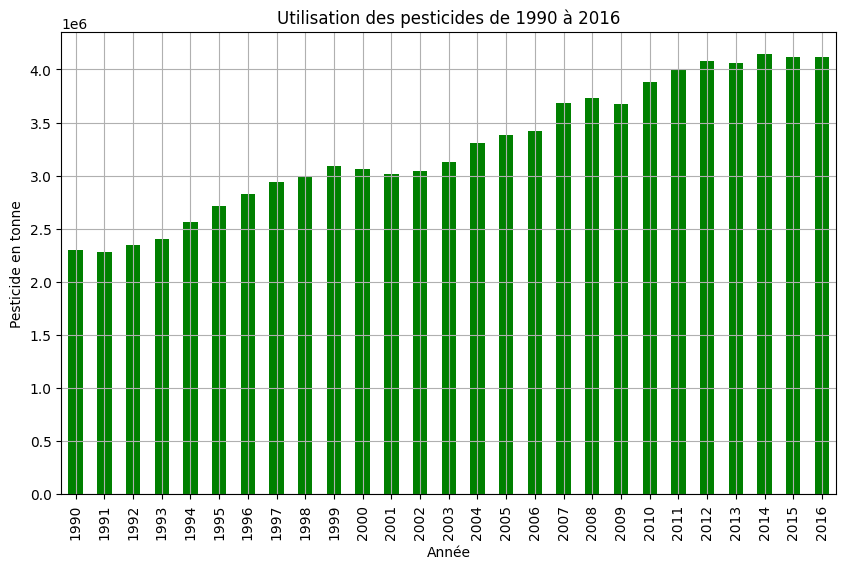

In [40]:
plt.figure(figsize=(10, 6))
hist_by_year = data_pesticides.groupby('Year')['Value'].sum()
# Histogramme
hist_by_year.plot(kind='bar', color='green')
plt.title("Utilisation des pesticides de 1990 à 2016")
plt.xlabel('Année')
plt.ylabel("Pesticide en tonne")
plt.grid()
plt.savefig('../notebooks/graph/histo_pesticide.png')

- Depuis les années 2000 jusqu'en 2006, on remarque une croissance de l'utilisation des pesticides de manière globale.
- Une petite en chute en 2009 avec une légère progression ensuite mais depuis 2011, l'utilisation reste constante.

## Chargement des données provenant du fichier "rainfall"

In [41]:
data_rainfall = pd.read_csv("../data/raw/rainfall.csv")

In [42]:
data_rainfall.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


### Informations du dataset

In [43]:
data_rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6727 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0    Area                          6727 non-null   object
 1   Year                           6727 non-null   int64 
 2   average_rain_fall_mm_per_year  5953 non-null   object
dtypes: int64(1), object(2)
memory usage: 157.8+ KB


In [44]:
data_rainfall.shape

(6727, 3)

Ici nous avons les informations concernant **les précipitations en mm par an**. On a
- 2 variables non numériques
- 1 variable numérique
- La variable principale ici va être "average_rain_fall_mm_per_year" qui est la valeur en mm des précipitations
- **On voit tout de suite une première erreur, la moyenne des précipitations est en texte et non en numérique.**
- On voit également que le nom d'une des variables contient un espace

Le jeu se compose de 3 colonnes et 6726 lignes

### Génération des statistiques descriptives

In [45]:
data_rainfall.describe()

,Year
count,6727.000000
mean,2001.354839
std,9.530114
min,1985.000000
25%,1993.000000
50%,2001.000000
75%,2010.000000
max,2017.000000


### Valeurs manquantes & doublons

In [46]:
print(f"Valeurs manquantes :\n{data_rainfall.isnull().mean()}")
print("-"*8)
print(f"Valeurs en doublons :\n{data_rainfall.duplicated(keep=False).any()}")
print(f"Valeurs en doublons sur les variables non-num clés :\n{data_rainfall.duplicated(['Year',' Area']).any()}")

Valeurs manquantes :
 Area                            0.000000
Year                             0.000000
average_rain_fall_mm_per_year    0.115059
dtype: float64
--------
Valeurs en doublons :
False
Valeurs en doublons sur les variables non-num clés :
False


- La variable average_rain_fall_mm_per_year contient des valeurs manquantes, ce qui explique aussi son erreur de format.
- Pas de doublons identifiés

### Analyse des valeurs manquantes

In [47]:
# Identification des pays avec des valeurs nulles
countries = data_rainfall.loc[
    data_rainfall['average_rain_fall_mm_per_year'].isnull(),
    ' Area'
].unique()
print(f"Liste des pays avec des valeurs nulles : \n{countries}")
print("\n============================\n")
# Récupération des pays où il y a au moins une valeur non nulle
result = data_rainfall.loc[
    (data_rainfall[' Area'].isin(countries)) &
    (data_rainfall['average_rain_fall_mm_per_year'].notna())
]
print(f"Liste des pays avec au moins une valeur non nulle : \n{result}")

Liste des pays avec des valeurs nulles : 
['American Samoa' 'Aruba' 'Bermuda' 'British Virgin Islands'
 'Cayman Islands' 'Channel Islands' 'Curacao' 'Faroe Islands'
 'French Polynesia' 'Gibraltar' 'Greenland' 'Guam' 'Hong Kong SAR, China'
 'Isle of Man' 'Kosovo' 'Macao SAR, China' 'Monaco' 'New Caledonia'
 'Northern Mariana Islands' 'San Marino' 'Sint Maarten (Dutch part)'
 'St. Martin (French part)' 'Tonga' 'Turks and Caicos Islands'
 'Virgin Islands (U.S.)']


Liste des pays avec au moins une valeur non nulle : 
        Area  Year average_rain_fall_mm_per_year
4061  Monaco  1985                            ..


- On retouve 25 pays sans valeurs pour la variable des précipitations.
- Monaco a une valeur non nulle mais qui est ".." alors aucun de ses 25 pays comportent une information concernant les précipitations

## Chargement des données provenant du fichier "temp"

In [48]:
data_temp = pd.read_csv("../data/raw/temp.csv")

In [49]:
data_temp.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


### Informations du dataset

In [50]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71311 entries, 0 to 71310
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      71311 non-null  int64  
 1   country   71311 non-null  object 
 2   avg_temp  68764 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ MB


In [51]:
data_temp.shape

(71311, 3)

Ici nous avons les informations concernant **les températures**. On a
- 1 variable non numérique
- 2 variables numériques
- La variable principale ici va être "avg_temp" qui est la température moyenne par pays, par année

Le jeu se compose de 3 colonnes et 71311 lignes

### Distribution température

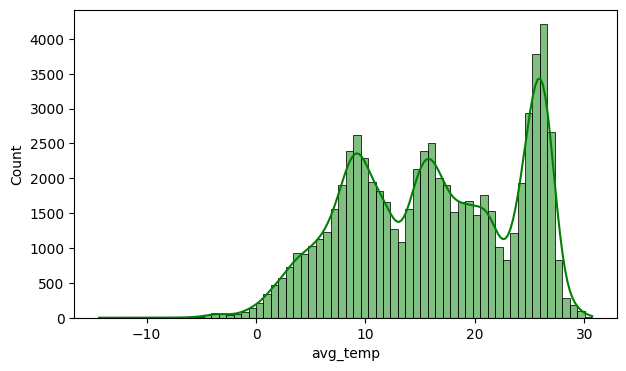

In [52]:
plt.figure(figsize=(7, 4))

# Histogramme + KDE
sns.histplot(data_temp['avg_temp'], kde=True, color="green")
plt.show()

- Étalement vers la droite, distribution non normale.
- On constate trois pics de température
- Les pays ayant un climat très différent, la distribution n'est pas choquante

### Génération des statistiques descriptives

In [53]:
data_temp.describe()

,year,avg_temp
count,71311.000000,68764.000000
mean,1905.799007,16.183876
std,67.102099,7.592960
min,1743.000000,-14.350000
25%,1858.000000,9.750000
50%,1910.000000,16.140000
75%,1962.000000,23.762500
max,2013.000000,30.730000


- On voit que nous avons la présence d'années très anciennes, avec un minimum à 1743, il faudra procéder à un tri.
- En terme de température, on va de -14 à 30 degrés, même si il ne paraît pas y avoir d'incohérence, on va quand même regarder les températures très basses.

#### Valeurs manquantes & doublons

In [54]:
print(f"Valeurs manquantes :\n{data_temp.isnull().mean()}")
print("-"*8)
print(f"Valeurs en doublons :\n{data_temp.duplicated(keep=False).any()}")
print(f"Valeurs en doublons sur les variables non-num clés :\n{data_temp.duplicated(['year','country']).any()}")

Valeurs manquantes :
year        0.000000
country     0.000000
avg_temp    0.035717
dtype: float64
--------
Valeurs en doublons :
True
Valeurs en doublons sur les variables non-num clés :
True


### Analyse des doublons

In [55]:
data_temp[data_temp.duplicated(subset=['country','year'],keep=False)].sort_values(by=["country","year"])

,year,country,avg_temp
16995,1855,Argentina,14.00
55853,1855,Argentina,14.22
16996,1856,Argentina,16.23
55854,1856,Argentina,16.80
16997,1857,Argentina,16.54
...,...,...,...
25949,2011,Vietnam,27.68
24568,2012,Vietnam,22.09
25950,2012,Vietnam,28.25
24569,2013,Vietnam,23.10


- On retouve des valeurs manquantes avce plusieurs températures disponibles pour une même année et un même pays.
- On a également la présence de doublons.

### Il y a peu de valeurs manquantes.
- On pourrait se dire que cela est dû à la récupération de données très ancienne. Essayons de reprendre les valeurs manquantes à partir des années 1900.

In [56]:
data_year = data_temp.loc[data_temp['year']>1900]
data_year.isnull().mean()

year        0.0
country     0.0
avg_temp    0.0
dtype: float64

- Si nous prenons que les années à partir de 1900, nous avons plus de valeurs manquantes. A garder en tête lorsque nous choisirons une temporalité

## Chargement des données provenant du fichier "yield_df"

In [57]:
data_yield_df = pd.read_csv("../data/raw/yield_df.csv")

In [58]:
data_yield_df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


### Informations du dataset

In [59]:
data_yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [60]:
data_yield_df.shape

(28242, 8)

Ici nous avons les informations regroupant les informations des trois datasets vu juste au dessus. On a
- 2 variables non numériques
- 6 variables numériques
- Les variables principales sont la tempétaure, les précipitations et les tonnes de pesticides

Le jeu se compose de 8 colonnes et 28242 lignes.

- **Nous décidons de ne pas partir de ce fichier pour les analyses car nous ne savons pas comment a été réalisé les différentes imputations, fusions etc**

### Génération des statistiques descriptives

In [61]:
data_yield_df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


#### Valeurs manquantes & doublons

In [62]:
print(f"Valeurs manquantes :\n{data_yield_df.isnull().mean()}")
print("-"*8)
print(f"Valeurs en doublons :\n{data_yield_df.duplicated(keep=False).any()}")
print(f"Valeurs en doublons sur les variables non-num clés :\n{data_yield_df.duplicated(['Area','Item','Year']).any()}")

Valeurs manquantes :
Unnamed: 0                       0.0
Area                             0.0
Item                             0.0
Year                             0.0
hg/ha_yield                      0.0
average_rain_fall_mm_per_year    0.0
pesticides_tonnes                0.0
avg_temp                         0.0
dtype: float64
--------
Valeurs en doublons :
False
Valeurs en doublons sur les variables non-num clés :
True


- Il y a bien eu une gestion des valeurs manquantes mais nous ne connaissons pas la méthodologie.
- On peut noter qu'il y a des doublons d'informations. Répetition en terme d'année par exemple.

### Exemple de duplication

In [63]:
duplicate_india =data_yield_df.loc[data_yield_df['Area']=='India']
duplicate_india.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
10502,10502,India,Cassava,1990,205381,1083.0,75000.0,25.58
10503,10503,India,Cassava,1990,205381,1083.0,75000.0,26.88
10504,10504,India,Cassava,1990,205381,1083.0,75000.0,25.79
10505,10505,India,Cassava,1990,205381,1083.0,75000.0,24.10
10506,10506,India,Cassava,1990,205381,1083.0,75000.0,25.25


- On voit ici par exemple pour l'Inde plusieurs température pour la même année, sur la même culture, cela fausse nos données.

## Chargement des données provenant du fichier "yield"

In [64]:
data_yield = pd.read_csv("../data/raw/yield.csv")

In [65]:
data_yield.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


### Informations du dataset

In [66]:
data_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Domain Code   56717 non-null  object
 1   Domain        56717 non-null  object
 2   Area Code     56717 non-null  int64 
 3   Area          56717 non-null  object
 4   Element Code  56717 non-null  int64 
 5   Element       56717 non-null  object
 6   Item Code     56717 non-null  int64 
 7   Item          56717 non-null  object
 8   Year Code     56717 non-null  int64 
 9   Year          56717 non-null  int64 
 10  Unit          56717 non-null  object
 11  Value         56717 non-null  int64 
dtypes: int64(6), object(6)
memory usage: 5.2+ MB


### Distribution de la variable cible

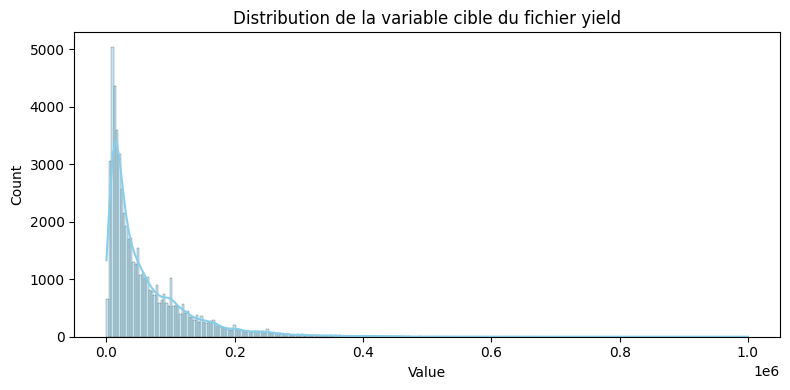

In [67]:
fig = plt.figure(figsize=(8, 4))

# Histogramme + KDE
sns.histplot(data_yield['Value'], kde=True, color="skyblue")
plt.title('Distribution de la variable cible du fichier yield')
plt.tight_layout()
plt.savefig('../notebooks/graph/distribution_variable_cible_fichier_yield.png')
plt.show()

In [68]:
data_yield.shape

(56717, 12)

Ici nous avons les informations concernant **le rendement** par pays, années et par culture. On a
- 6 variables non numériques
- 6 variables numériques
- La variable principale ici va être "Value" qui est la valeur du rendement.
- On y voit déjà des colonnes inutiles d'un point de vu métier comme Area Code / Element Code / Element / Item Code ou encore Year Code

Le jeu se compose de 12 colonnes et 56717 lignes

- **C'est le fichier central du dossier des Prédictions, nous allons fusionner les données des trois autres fichiers avec celui-ci.**

### Boxplot du rendement par culture

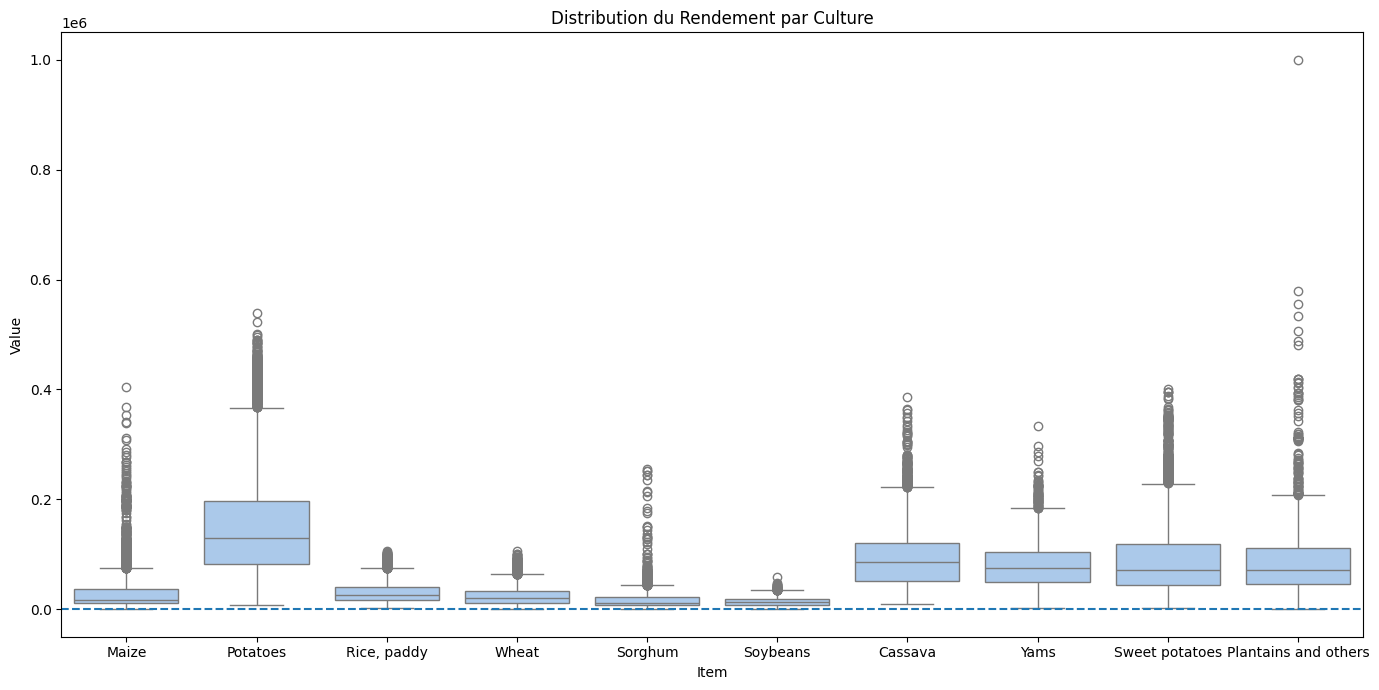

In [69]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=data_yield, x="Item", y="Value", color="#a1c9f4")
plt.title("Distribution du Rendement par Culture")
# Ligne horizontale à y = 0
plt.axhline(y=0, linestyle='--')
plt.tight_layout()
plt.savefig('../notebooks/graph/boxplot_yield.png')


- On peut voir quelques valeurs à 0. Difficile de savoir si on les supprime ou non car théoriquement un rendement à 0 c'est possible si les conditions ne sont pas réunies pour une production.
- On voit une valeur énorme pour Plaintains and more - à analyser
- On voit un fort déséquilibre entre les types de culture. On peut noter que la catégorie Potatoes semble avoir avoir des rendements plus élevés que les autres. Ce sont des valeurs extrêmes mais pas aberrantes car elles sont réelles alors nous devons les laisser. 

In [70]:
data_yield.loc[data_yield['Value'].idxmax()]

Domain Code                       QC
Domain                         Crops
Area Code                        114
Area                           Kenya
Element Code                    5419
Element                        Yield
Item Code                        489
Item            Plantains and others
Year Code                       1964
Year                            1964
Unit                           hg/ha
Value                        1000000
Name: 27930, dtype: object

- On voit que la valeur extrême date de 1964, nous irons pas dans des dates aussi antérieurs donc on l'enlevera par défaut par la suite.

### Génération des statistiques descriptives

In [71]:
data_yield.describe()

,Area Code,Element Code,Item Code,Year Code,Year,Value
count,56717.000000,56717.0,56717.000000,56717.000000,56717.000000,56717.000000
mean,125.650422,5419.0,111.611651,1989.669570,1989.669570,62094.660084
std,75.120195,0.0,101.278435,16.133198,16.133198,67835.932856
min,1.000000,5419.0,15.000000,1961.000000,1961.000000,0.000000
25%,58.000000,5419.0,56.000000,1976.000000,1976.000000,15680.000000
50%,122.000000,5419.0,116.000000,1991.000000,1991.000000,36744.000000
75%,184.000000,5419.0,125.000000,2004.000000,2004.000000,86213.000000
max,351.000000,5419.0,489.000000,2016.000000,2016.000000,1000000.000000


### Nous avons des valeurs à 0 (voir le tableau ci-dessus). Après analyse de ces valeurs, il est difficile d'être sûr à 100% de la véracité des informations

#### Valeurs manquantes & doublons

In [72]:
print(f"Valeurs manquantes :\n{data_yield.isnull().mean()}")
print("-"*8)
print(f"Valeurs en doublons :\n{data_yield.duplicated(keep=False).any()}")
print(f"Valeurs en doublons sur les variables non-num clés :\n{data_yield.duplicated(['Area','Item','Year']).any()}")

Valeurs manquantes :
Domain Code     0.0
Domain          0.0
Area Code       0.0
Area            0.0
Element Code    0.0
Element         0.0
Item Code       0.0
Item            0.0
Year Code       0.0
Year            0.0
Unit            0.0
Value           0.0
dtype: float64
--------
Valeurs en doublons :
False
Valeurs en doublons sur les variables non-num clés :
False


- Pas de présence de valeurs manquantes ou de doublons

Un des plus gros travail ici va d'essayer d'être le plus cohérent possible :

- Utiliser des noms de variables plus explicites
- Choisir une temporalité bien définit

Pour ce faire nous devons rationaliser par rapport aux autres fichiers, nous avons plusieurs problématiques :

- La temporalité n'est pas identique sur l'ensemble des datasets
- Le noms des pays semblent différent pour certains d'entres eux
- Première chose à faire va être de sélectionner une temporalité restreinte, on va sélectionner à partir de l'année 1990
- Deuxième chose à faire va être d'identifier les noms des pays à changer, seulement ceux qui vont nous paraître les plus évidents (pour ne pas se perdre dans ce sujet)

# Fichier clean pour le dataset final

### Construction d’un dataset de prédiction propre et cohérent

Dans un premier temps, une analyse du fichier yield_df.csv a été réalisée. Celle-ci a mis en évidence plusieurs limites, notamment la présence de doublons sur la clé métier (Area, Item, Year) ainsi que des incohérences liées à la fusion initiale des données (en particulier sur la variable de température). Ce fichier n’a donc pas été retenu comme base principale pour la modélisation.
Afin de garantir la qualité et la cohérence des données, le dataset final a été reconstruit à partir des sources brutes suivantes : yield.csv, temp.csv, rainfall.csv et pesticides.csv.

Plusieurs étapes de préparation vont être mis en place :

- Harmonisation des noms de pays pour assurer la compatibilité entre les différentes sources
- Restriction à la période commune (1990–2016) afin d’éviter des valeurs manquantes excessives, notamment sur les données de température et avoir des années récentes
- Fusion progressive des datasets en conservant yield.csv comme base principale
- Création de variables indicatrices de valeurs manquantes pour conserver l’information liée à l’absence de données --> utilisation des quartiles
- Imputation des valeurs manquantes en fonction des "bins" afin de ne pas imputer des valeurs globales qui pourraient fausser les données
- Cela va nous permettre de limiter la suppression des données

**Le dataset final ainsi obtenu constitue une base fiable et exploitable --> possibilité de rajouter ensuite un enrichissement des données avec le fichier crop_yield**

In [73]:
data_pesticides = pd.read_csv("../data/raw/pesticides.csv")
data_rainfall = pd.read_csv("../data/raw/rainfall.csv")
data_temp = pd.read_csv("../data/raw/temp.csv")
data_yield = pd.read_csv("../data/raw/yield.csv")
data_yield_df = pd.read_csv("../data/raw/yield_df.csv")

### Harmonisation des pays pour l'ensemble des fichiers du dataset prédiction
- Utilisation d'un LLM pour identifier les pays mal nommés et proposition d'un nom standardisé par pays.
- Fichier d'harmonisation dans data/processed

#### Reprenons nos fichiers bruts
- Pour l'harmonisation des pays, nous allons nous appuyer sur un LLM.
- **L'idée est qu'il puisse nous donner un fichier comportant plusieurs noms d'un pays avec un nom standard afin d'obtenir les mêmes noms dans tous les fichiers.**

In [74]:
# On enregistre la liste des pays actuel en CSV pour pouvoir les envoyer au LLM
# Pays dans yield
country_list_yield = pd.DataFrame(data_yield['Area'].unique(), columns=["Area"])
country_list_yield.to_csv('../data/processed/harmonization_data/initial_country_list_yield.csv', index = False)
# Pays dans rainfall
country_list = pd.DataFrame(data_rainfall[' Area'].unique(), columns=["Area"])
country_list.to_csv('../data/processed/harmonization_data/initial_country_list_rainfall.csv', index = False)
# Pays dans pesticide
country_list_presticides = pd.DataFrame(data_pesticides['Area'].unique(), columns=["Area"])
country_list_presticides.to_csv('../data/processed/harmonization_data/initial_country_list_pesticides.csv', index = False)
# Pays dans temp
country_list_temp = pd.DataFrame(data_temp['country'].unique(), columns=["Area"])
country_list_temp.to_csv('../data/processed/harmonization_data/initial_country_list_temp.csv', index = False)
# Enregistrement des fichiers
print('Pays unique par fichier enregistré dans data/processed/harmonization_data')

Pays unique par fichier enregistré dans data/processed/harmonization_data


#### Récupération du fichier de corresondance généré par un LLM

In [75]:
# Chargement de la liste des pays pour harmonisation dans data/processed
mapping_df = pd.read_csv('../data/processed/harmonization_data/country_standardization_mapping.csv')
# On met les informations dans un dictionnaire afin de pouvoir les mapper
mapping_dict = dict(zip(mapping_df['Original Name'], mapping_df['Standard Name']))
# Identification d'une erreur supplémentaire
mapping_dict.update({
    "Bosnia And Herzegovina": "Bosnia and Herzegovina"
})

#### Mapping des fichiers avec le nom standard des pays

In [76]:
# Mapping des fichiers
# Fichier yield
data_yield_map = data_yield.copy()
data_yield_map['Area'] = data_yield_map['Area'].map(mapping_dict).fillna(data_yield_map['Area'])
# Fichier rainfall
data_rainfall_map = data_rainfall.copy()
data_rainfall_map[' Area'] = data_rainfall_map[' Area'].map(mapping_dict).fillna(data_rainfall_map[' Area'])
# Fichier pesticide
data_pesticides_map = data_pesticides.copy()
data_pesticides_map['Area'] = data_pesticides_map['Area'].map(mapping_dict).fillna(data_pesticides_map['Area'])
# Fichier temp
data_temp_map = data_temp.copy()
data_temp_map['country'] = data_temp_map['country'].map(mapping_dict).fillna(data_temp_map['country'])

### Comparaison nombre de pays avant et après

In [77]:
def get_mapping_stats(original_df, column_name, mapping_dict, label):
    # Liste unique avant mapping
    original_countries = set(original_df[column_name].unique())
    
    # Simulation du mapping pour voir ce qui change
    # On regarde si la clé existe dans le dict et si la valeur de destination est différente
    changed_countries = {
        name for name in original_countries 
        if name in mapping_dict and mapping_dict[name] != name
    }
    
    print(f"--- Rapport pour {label} ---")
    print(f"Nombre total de pays uniques : {len(original_countries)}")
    print(f"Nombre de pays modifiés : {len(changed_countries)}")
    if changed_countries:
        print("Exemples de modifications :")
        for name in list(changed_countries)[:5]: # Affiche les 5 premiers pour ne pas surcharger
            print(f"  - {name} -> {mapping_dict[name]}")
    print("\n")
    return changed_countries

# Application du calcul pour chaque DataFrame
changed_yield = get_mapping_stats(data_yield, 'Area', mapping_dict, "Yield")
changed_rainfall = get_mapping_stats(data_rainfall, ' Area', mapping_dict, "Rainfall")
changed_pesticide = get_mapping_stats(data_pesticides, 'Area', mapping_dict, "Pesticides")
changed_temp = get_mapping_stats(data_temp, 'country', mapping_dict, "Temperature")

# Total global (tous fichiers confondus)
all_changed = changed_yield | changed_rainfall | changed_pesticide | changed_temp
print(f"TOTAL : {len(all_changed)} pays uniques ont été harmonisés sur l'ensemble du projet.")

--- Rapport pour Yield ---
Nombre total de pays uniques : 212
Nombre de pays modifiés : 28
Exemples de modifications :
  - Cabo Verde -> Cape Verde
  - Eswatini -> Swaziland
  - Democratic Republic of the Congo -> DR Congo
  - Brunei Darussalam -> Brunei
  - United Republic of Tanzania -> Tanzania


--- Rapport pour Rainfall ---
Nombre total de pays uniques : 217
Nombre de pays modifiés : 15
Exemples de modifications :
  - Venezuela, RB -> Venezuela
  - Hong Kong SAR, China -> Hong Kong
  - Congo, Dem. Rep. -> DR Congo
  - Cabo Verde -> Cape Verde
  - Lao PDR -> Laos


--- Rapport pour Pesticides ---
Nombre total de pays uniques : 168
Nombre de pays modifiés : 24
Exemples de modifications :
  - Cabo Verde -> Cape Verde
  - Brunei Darussalam -> Brunei
  - United Republic of Tanzania -> Tanzania
  - United States of America -> United States
  - Saint Kitts and Nevis -> St. Kitts and Nevis


--- Rapport pour Temperature ---
Nombre total de pays uniques : 137
Nombre de pays modifiés : 5
Ex

### Vérification que les noms sont identiques entre df

In [78]:
# Récupérer tous les noms de pays
all_countries = pd.concat([
    data_yield_map["Area"],
    data_rainfall_map[" Area"],
    data_pesticides_map["Area"],
    data_temp_map["country"]
]).dropna().astype(str).str.strip()

# Mettre en minuscule pour comparer
check = pd.DataFrame({
    "original": all_countries,
    "normalized": all_countries.str.lower()
})

# Voir s'il existe plusieurs écritures pour un même pays
duplicates = check.groupby("normalized")["original"].nunique()

# Résultat
if (duplicates > 1).any():
    print("Il reste des noms incohérents :")
    print(duplicates[duplicates > 1])
else:
    print("Tous les pays ont un nom cohérent")

Tous les pays ont un nom cohérent


### Nombre d'années disponibles par fichier

In [79]:
print("Période yield :", data_yield["Year"].min(), "->", data_yield["Year"].max())
print("Période temp :", data_temp["year"].min(), "->", data_temp["year"].max())
print("Période rainfall :", data_rainfall["Year"].min(), "->", data_rainfall["Year"].max())
print("Période pesticides :", data_pesticides["Year"].min(), "->", data_pesticides["Year"].max())

Période yield : 1961 -> 2016
Période temp : 1743 -> 2013
Période rainfall : 1985 -> 2017
Période pesticides : 1990 -> 2016


- On voit que nous ne sommes pas sur la même temporalité, on sélectionne la période :
- **1990 --> 2016**
- En ayant conscience de l'absence de 3 ans pour la donnée température

### Nettoyage des différents fichiers avant une fusion

In [80]:
# ==============
# Fichier yield
# ==============
# Restriction à la période commune 1990-2013
data_yield_map = data_yield_map[data_yield_map["Year"].between(1990, 2016)].copy()

# On garde les colonnes utiles
# On enlève notamment Domain Code / Area Code / Element Code / Item Code / Unit
data_yield_map = data_yield_map[["Area", "Item", "Year", "Value"]].copy()

# On renomme correctement le nom de la variable cible
data_yield_map = data_yield_map.rename(columns={"Area":"area",
                                                "Item":"item",
                                                "Year":"year",
                                                "Value":"yield"}).copy()

# Vérification des doublons métier
print("Doublons sur (Area, Item, Year) dans yield :", data_yield_map.duplicated(["area","item", "year"]).sum())
print("Valeurs manquantes dans yield : \n", data_yield_map.isnull().mean())

data_yield_map.head(2)

Doublons sur (Area, Item, Year) dans yield : 216
Valeurs manquantes dans yield : 
 area     0.0
item     0.0
year     0.0
yield    0.0
dtype: float64


,area,item,year,yield
29,Afghanistan,Maize,1990,17582
30,Afghanistan,Maize,1991,16800


- Identification de doublons après l'harmonisation des pays

In [81]:
data_yield_map.loc[data_yield_map.duplicated(subset=["area", "item", "year"],keep=False),'area'].unique()

array(['China'], dtype=object)

- En fouillant dans le premier dataset on voit qu'il y a un doublons sur la Chine, avec la valeur "China" & "China, mainland"

In [82]:
# On supprime les doublons trouvés
data_yield_map = data_yield_map.drop_duplicates(subset=["area", "item", "year"]).copy()
print(f"Nombre de doublons après le nettoyage des données concernant la Chine --> {data_yield_map.duplicated(["area", "item", "year"]).sum()}")

Nombre de doublons après le nettoyage des données concernant la Chine --> 0


In [83]:
# ===================
# Fichier pesticides
# ===================
# Restriction à la période commune 1990-2013
data_pesticides_map = data_pesticides_map[data_pesticides_map["Year"].between(1990, 2016)].copy()

# On garde les colonnes utiles
# On enlève notamment Domain Code / Area Code / Element Code / Item Code / Unit
data_pesticides_map = data_pesticides_map[["Area", "Year", "Value"]].copy()

# On renomme correctement le nom de la variable cible
data_pesticides_map = data_pesticides_map.rename(columns={"Area":"area",
                                                          "Year":"year",
                                                          "Value":"pesticides_tonnes"}).copy()

# Vérification des doublons métier
print("Doublons sur (Area, Year) dans pesticides :", data_pesticides_map.duplicated(["area", "year"]).sum())
print("Valeurs manquantes dans pesticides : \n", data_pesticides_map.isnull().mean())

data_pesticides_map.head(2)

Doublons sur (Area, Year) dans pesticides : 0
Valeurs manquantes dans pesticides : 
 area                 0.0
year                 0.0
pesticides_tonnes    0.0
dtype: float64


,area,year,pesticides_tonnes
0,Albania,1990,121.0
1,Albania,1991,121.0


In [84]:
# ===================
# Fichier rainfall
# ===================
# Restriction à la période commune 1990-2013
data_rainfall_map = data_rainfall_map[data_rainfall_map["Year"].between(1990, 2016)].copy()

# On renomme correctement 2 variables
data_rainfall_map = data_rainfall_map.rename(columns={" Area": "area",
                                                      "Year":"year",
                                                      "average_rain_fall_mm_per_year": "rainfall_mm"}).copy()

# Conversion numérique en forçant malgrés les NaN
data_rainfall_map["rainfall_mm"] = pd.to_numeric(data_rainfall_map["rainfall_mm"],errors="coerce")

# Vérification des doublons métier
print("Doublons sur (Area, Year) dans rainfall :", data_rainfall_map.duplicated(["area", "year"]).sum())
print("Valeurs manquantes dans rainfall : \n", data_rainfall_map.isnull().mean())

data_rainfall_map.head()

Doublons sur (Area, Year) dans rainfall : 0
Valeurs manquantes dans rainfall : 
 area           0.000000
year           0.000000
rainfall_mm    0.115562
dtype: float64


,area,year,rainfall_mm
4,Afghanistan,1990,327.0
5,Afghanistan,1991,327.0
6,Afghanistan,1992,327.0
7,Afghanistan,1993,327.0
8,Afghanistan,1994,327.0


- On note toujours la présence de valeurs manquantes, nous les traiterons lors de la fusion.

In [85]:
# ===================
# Fichier temp
# ===================
# Restriction à la période commune 1990-2013
data_temp_map = data_temp_map[data_temp_map["year"].between(1990, 2016)].copy()

# On renomme correctement 2 variables
data_temp_map = data_temp_map.rename(columns={"country": "area"}).copy()

# Agrégation propre au couple Area-Year
# Imputation par la moyenne pour les années manquantes par pays / Imputation logique ici avant imputation globale
data_temp_map = (
    data_temp_map
    .groupby(["area", "year"], as_index=False)["avg_temp"]
    .median()
).copy()

# Vérification des doublons métier
print("Doublons sur (Area, Year) dans temp :", data_temp_map.duplicated(["area", "year"]).sum())
print("Valeurs manquantes dans temp : \n", data_temp_map.isnull().mean())
data_temp_map.head()

Doublons sur (Area, Year) dans temp : 0
Valeurs manquantes dans temp : 
 area        0.0
year        0.0
avg_temp    0.0
dtype: float64


,area,year,avg_temp
0,Afghanistan,1990,15.45
1,Afghanistan,1991,14.57
2,Afghanistan,1992,14.35
3,Afghanistan,1993,14.96
4,Afghanistan,1994,14.94


- A noter que nous aurons toujours ce delta dans la fusion globale lié aux 3 années manquantes

### Quelques vérifications

In [86]:
print("Nombre de lignes et colonnes avant et après :\n")
print(f"Yield avant changement : {data_yield.shape}, après changement : {data_yield_map.shape}")
print(f"Temp avant changement : {data_temp.shape}, après changement : {data_temp_map.shape}")
print(f"Rainfall avant changement : {data_rainfall.shape}, après changement : {data_rainfall_map.shape}")
print(f"Pesticides avant changement : {data_pesticides.shape}, après changement : {data_pesticides_map.shape}")

Nombre de lignes et colonnes avant et après :

Yield avant changement : (56717, 12), après changement : (29151, 4)
Temp avant changement : (71311, 3), après changement : (3288, 3)
Rainfall avant changement : (6727, 3), après changement : (5642, 3)
Pesticides avant changement : (4349, 7), après changement : (4349, 3)


- **La différence pour le fichier temp est expliqué par le fait que dans les données de abse il y avait une temporalité commençant en 1743 + des doublons par année.**

In [87]:
print("Période yield :", data_yield_map["year"].min(), "->", data_yield_map["year"].max())
print("Période temp :", data_temp_map["year"].min(), "->", data_temp_map["year"].max())
print("Période rainfall :", data_rainfall_map["year"].min(), "->", data_rainfall_map["year"].max())
print("Période pesticides :", data_pesticides_map["year"].min(), "->", data_pesticides_map["year"].max())

Période yield : 1990 -> 2016
Période temp : 1990 -> 2013
Période rainfall : 1990 -> 2016
Période pesticides : 1990 -> 2016


### Fusion des datasets

In [88]:
# La fusion se réalise sur le fichier que l'on considère comme principal --> yield / d'où le merge "left"
df_predictions = data_yield_map.copy()

yield_temp = df_predictions.merge(
    data_temp_map,
    on=["area", "year"],
    how="left"
)

yield_temp_rain = yield_temp.merge(
    data_rainfall_map,
    on=["area", "year"],
    how="left"
)

yield_final = yield_temp_rain.merge(
    data_pesticides_map,
    on=["area", "year"],
    how="left"
)

yield_final.head()

,area,item,year,yield,avg_temp,rainfall_mm,pesticides_tonnes
0,Afghanistan,Maize,1990,17582,15.45,327.0,NaN
1,Afghanistan,Maize,1991,16800,14.57,327.0,NaN
2,Afghanistan,Maize,1992,15000,14.35,327.0,NaN
3,Afghanistan,Maize,1993,16786,14.96,327.0,NaN
4,Afghanistan,Maize,1994,16667,14.94,327.0,NaN


In [89]:
print("Shape yield_final :", yield_final.shape)
print("Doublons sur (Area, Item, Year) :", yield_final.duplicated(["area", "item", "year"]).sum())
print("\nTaux de valeurs manquantes :")
print(yield_final.isnull().mean().sort_values(ascending=False))

Shape yield_final : (29151, 7)
Doublons sur (Area, Item, Year) : 0

Taux de valeurs manquantes :
avg_temp             0.363521
pesticides_tonnes    0.171452
rainfall_mm          0.102261
area                 0.000000
item                 0.000000
year                 0.000000
yield                0.000000
dtype: float64


- Présence de NaN, notre prochain objectif va être de les imputer de la manière la plus cohérente possible.

### Ajout des régions par pays pour permettre une imputation plus fine
- Ensuite nous voulons améliorer la distinction des pays alors nous avons sélectionné un dataset afin d'ajouter les grandes régions par pays
    - https://unstats.un.org/unsd/methodology/m49/overview/ : dataset sélectionné
    - Pour cela nous devons faire matcher encore une fois le noms des pays avec le dataset, nous verrons que devrons modifier "à la main" 37 pays qui ne correspondaient pas

In [90]:
# On charge le fichier des Nations Unies
united_nations_files = pd.read_csv("../data/raw/UNSD — Methodology.csv",sep=";")
# On merge par pays pour obtenir les régions du monde
merge_region = yield_final.merge(united_nations_files[["Country or Area","Sub-region Name"]],
                                                     left_on = "area",
                                                     right_on = "Country or Area",
                                                     how="left")
merge_region.isnull().mean()

area                 0.000000
item                 0.000000
year                 0.000000
yield                0.000000
avg_temp             0.363521
rainfall_mm          0.102261
pesticides_tonnes    0.171452
Country or Area      0.164214
Sub-region Name      0.164214
dtype: float64

- On a 16% de région qui manque, le mapping entre pays est compliqué car les différentes sources n'ont pas forcément le même nom. Nous allons les harmoniser "à la main" pour s'assurer d'une bonne cohérence.

In [91]:
missed_sub_region = merge_region.loc[merge_region['Sub-region Name'].isnull(),"area"]
missed_sub_region.unique()

array(['Belgium-Luxembourg', 'Bolivia', 'Brunei', 'Cape Verde',
       'Hong Kong', 'Taiwan', 'Republic of the Congo', "Cote d'Ivoire",
       'Czech Republic', 'Czechoslovakia', 'North Korea', 'DR Congo',
       'Ethiopia PDR', 'Iran', 'Laos', 'Micronesia', 'Netherlands',
       'Palestine', 'Pacific Islands Trust Territory', 'South Korea',
       'Moldova', 'Russia', 'St. Kitts and Nevis', 'St. Lucia',
       'St. Vincent and the Grenadines', 'Serbia and Montenegro',
       'Sudan (former)', 'Swaziland', 'Syria', 'Turkey', 'United Kingdom',
       'Tanzania', 'United States', 'USSR', 'Venezuela', 'Vietnam',
       'Yugoslav SFR'], dtype=object)

In [92]:
# Dictionnaire de correspondance aligné sur les "bons éléments"
missing_subregions = {
    'Belgium-Luxembourg': 'Western Europe',
    'Bolivia': 'Latin America and the Caribbean',
    'Brunei': 'South-eastern Asia',
    'Cape Verde': 'Sub-Saharan Africa',
    'Hong Kong': 'Eastern Asia',
    'Taiwan': 'Eastern Asia',
    'Republic of the Congo': 'Sub-Saharan Africa',
    "Cote d'Ivoire": 'Sub-Saharan Africa',
    'Czech Republic': 'Eastern Europe',
    'Czechoslovakia': 'Eastern Europe',
    'North Korea': 'Eastern Asia',
    'DR Congo': 'Sub-Saharan Africa',
    'Ethiopia PDR': 'Sub-Saharan Africa',
    'Iran': 'Southern Asia',
    'Laos': 'South-eastern Asia',
    'Micronesia': 'Micronesia',
    'Netherlands': 'Western Europe',
    'Palestine': 'Western Asia',
    'Pacific Islands Trust Territory': 'Micronesia',
    'South Korea': 'Eastern Asia',
    'Moldova': 'Eastern Europe',
    'Russia': 'Eastern Europe',
    'St. Kitts and Nevis': 'Latin America and the Caribbean',
    'St. Lucia': 'Latin America and the Caribbean',
    'St. Vincent and the Grenadines': 'Latin America and the Caribbean',
    'Serbia and Montenegro': 'Southern Europe',
    'Sudan (former)': 'Northern Africa',
    'Swaziland': 'Sub-Saharan Africa',
    'Syria': 'Western Asia',
    'Turkey': 'Western Asia',
    'United Kingdom': 'Northern Europe',
    'Tanzania': 'Sub-Saharan Africa',
    'United States': 'Northern America',
    'USSR': 'Eastern Europe',
    'Venezuela': 'Latin America and the Caribbean',
    'Vietnam': 'South-eastern Asia',
    'Yugoslav SFR': 'Southern Europe'
}

# Application ciblée : on ne met à jour que si le nom est dans notre liste de manquants
# Cela permet de ne pas toucher aux "bons éléments" déjà présents pour les autres pays
merge_region['Sub-region Name'] = merge_region.apply(
    lambda row: missing_subregions.get(row['area'], row['Sub-region Name']), 
    axis=1
)

# Vérification des résultats
print(f"Nombre de valeurs manquantes restantes : {merge_region['Sub-region Name'].isna().sum()}")
# Affichage de quelques pays mis à jour pour vérification
print(merge_region[merge_region['area'].isin(['Bolivia', 'USSR', 'Vietnam'])][['area', 'Sub-region Name']])

Nombre de valeurs manquantes restantes : 0
          area                  Sub-region Name
2656   Bolivia  Latin America and the Caribbean
2657   Bolivia  Latin America and the Caribbean
2658   Bolivia  Latin America and the Caribbean
2659   Bolivia  Latin America and the Caribbean
2660   Bolivia  Latin America and the Caribbean
...        ...                              ...
28513  Vietnam               South-eastern Asia
28514  Vietnam               South-eastern Asia
28515  Vietnam               South-eastern Asia
28516  Vietnam               South-eastern Asia
28517  Vietnam               South-eastern Asia

[417 rows x 2 columns]


### Valeurs manquantes

In [93]:
merge_region.isnull().mean()

area                 0.000000
item                 0.000000
year                 0.000000
yield                0.000000
avg_temp             0.363521
rainfall_mm          0.102261
pesticides_tonnes    0.171452
Country or Area      0.164214
Sub-region Name      0.000000
dtype: float64

### Vérification de la cohérence du nom des pays

In [94]:
with pd.option_context('display.max_rows', None):
    print(merge_region.groupby(['Sub-region Name', 'area'])['area'].count())

Sub-region Name                  area                           
Australia and New Zealand        Australia                          189
                                 New Zealand                        108
Central Asia                     Kazakhstan                         150
                                 Kyrgyzstan                         150
                                 Tajikistan                         149
                                 Turkmenistan                       100
                                 Uzbekistan                         125
Eastern Asia                     China                              216
                                 Hong Kong                           47
                                 Japan                              189
                                 Mongolia                            54
                                 North Korea                        189
                                 South Korea                        189

### Suppression de la colonne "Country or Area" qui n'a plus d'utilité ici

In [95]:
merge_region = merge_region.drop(columns="Country or Area")
yield_final = merge_region.copy()

### Regoupement des pays
- Nous observons des valeurs manquantes pour les 3 variables que nous avons rajouté. La difficulté est de réussir à rester cohérent. Nous ne connaissons pas parfaitement la source des données alors il faut imputer les NaN de manière subtile.
- L'idée est bien d'imputer et de ne pas supprimer car nous voulons perdre le moins de données possible.

#### Regroupement des pays par critères agricoles et climatiques pertinents

On utilise les variables existantes pour définir des groupes :

- **Utilisation des quartiles par variable afin d'identifier des "groupes" de pays**. On avait pensé à la méthode des k-means également mais la méthode nécessite d'avoir déjà une meilleure gestion des NaN alors que l'objectif ici est de les imputer.
- Ensuite on regroupe par région et par type de culture pour avoir une imputation la plus propre possible

In [96]:
# Imputation minimale si présence d'une valeur pour le couple pays-items on ajoute la médiane
for col in ["avg_temp", "rainfall_mm", "pesticides_tonnes"]:
    yield_final[col] = yield_final[col].fillna(
        yield_final.groupby(["area", "item"])[col].transform("median")
    )
    yield_final[col] = yield_final[col].fillna(yield_final[col].median())

# Création des groupes climatiques
yield_final["temp_group"] = pd.qcut(yield_final["avg_temp"], q=4, labels=False)
yield_final["rainfall_group"] = pd.qcut(yield_final["rainfall_mm"], q=4, labels=False)
yield_final["pesticides_group"] = pd.qcut(yield_final["pesticides_tonnes"], q=4, labels=False)

# Création du groupe final
yield_final["agro_group"] = (
    yield_final["Sub-region Name"].astype(str) + "_" +
    yield_final["item"].astype(str) + "_" +
    yield_final["temp_group"].astype(str) + "_" +
    yield_final["rainfall_group"].astype(str) + "_" +
    yield_final["pesticides_group"].astype(str)
)

# Imputation en fonction du nouveau groupe
for col in ["avg_temp", "rainfall_mm", "pesticides_tonnes"]:
    yield_final[col] = yield_final[col].fillna(
        yield_final.groupby("agro_group")[col].transform("median")
    )

### Vérification des doublons

In [97]:
yield_final.isnull().mean()

area                 0.0
item                 0.0
year                 0.0
yield                0.0
avg_temp             0.0
rainfall_mm          0.0
pesticides_tonnes    0.0
Sub-region Name      0.0
temp_group           0.0
rainfall_group       0.0
pesticides_group     0.0
agro_group           0.0
dtype: float64

- Le traitement des valeurs manquantes a été correctement effectué

### Sélection des colonnes utiles

In [98]:
# On renomme la nouvelle variable
yield_final = yield_final.rename(columns={"Sub-region Name":"region"}).copy()
# On sélectionne les colonnes utiles
cols = ['area','region','year','item','avg_temp','rainfall_mm','pesticides_tonnes','yield']
yield_final = yield_final[cols].copy()

## Sauvegarde du nouveau fichier

In [99]:
yield_final.to_csv('../data/processed/yield_df_final.csv')

## Distribution de la variable cible

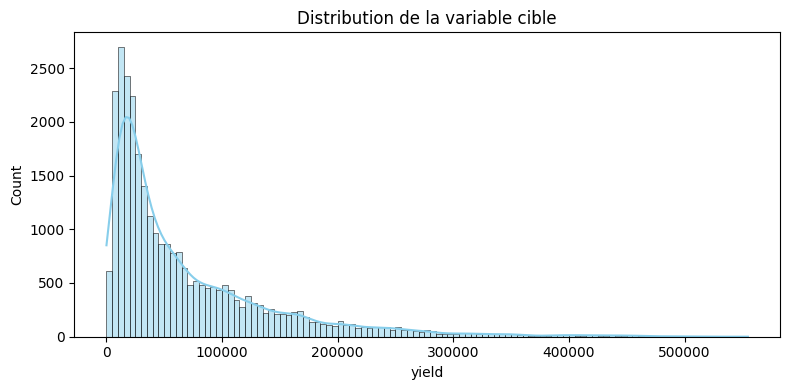

In [100]:
fig = plt.figure(figsize=(8, 4))

# Histogramme + KDE
sns.histplot(yield_final['yield'], kde=True, color="skyblue")
plt.title('Distribution de la variable cible')
plt.tight_layout()
plt.savefig('../notebooks/graph/distribution_variable_cible.png')
plt.show()

- La forme de la distribution de notre varibale cible est bien toujours étalé à gauche, nous ne sommes pas en présence d'une distribution normale. On observe une concentration de rendement entre 0 et 100 000.

In [101]:
yield_final.loc[yield_final['yield']<=10000,:]

,area,region,year,item,avg_temp,rainfall_mm,pesticides_tonnes,yield
13,Afghanistan,Southern Asia,2003,Maize,15.130,327.0,1594.50,8400
91,Afghanistan,Southern Asia,2000,Wheat,15.820,327.0,1594.50,7240
92,Afghanistan,Southern Asia,2001,Wheat,15.850,327.0,1594.50,8977
167,Albania,Southern Europe,1991,Sorghum,15.360,1485.0,121.00,6667
168,Albania,Southern Europe,1992,Sorghum,16.060,1485.0,121.00,3747
...,...,...,...,...,...,...,...,...
29066,Zimbabwe,Sub-Saharan Africa,2013,Sorghum,19.760,657.0,2550.07,3066
29067,Zimbabwe,Sub-Saharan Africa,2014,Sorghum,20.765,657.0,2185.07,4589
29068,Zimbabwe,Sub-Saharan Africa,2015,Sorghum,20.765,657.0,2185.07,2412
29069,Zimbabwe,Sub-Saharan Africa,2016,Sorghum,20.765,657.0,2185.07,2688


### Corrélation
- Utilisation de la méthode spearman car nous sommes face à une distribution non linéaire.

In [102]:
# Tableau des corrélations
cols_num = ['avg_temp','rainfall_mm','pesticides_tonnes','yield']
spearman_corr = yield_final[cols_num].corr(numeric_only=True, method='spearman')
spearman_corr

,avg_temp,rainfall_mm,pesticides_tonnes,yield
avg_temp,1.000000,0.369049,-0.328893,-0.077807
rainfall_mm,0.369049,1.000000,-0.016414,0.038608
pesticides_tonnes,-0.328893,-0.016414,1.000000,0.156642
yield,-0.077807,0.038608,0.156642,1.000000


### Matrice des corrélations
Utilisation de la méthode spearman car nous ne sommes pas dans le cadre d'une distribution normale.

<function matplotlib.pyplot.show(close=None, block=None)>

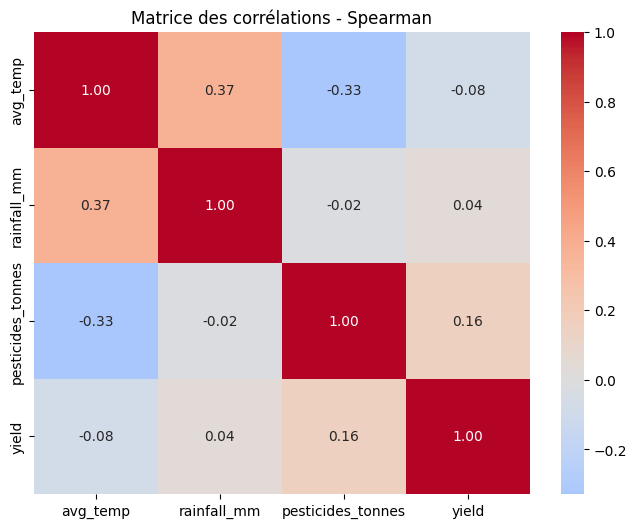

In [103]:
# Matrice des corrélations
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Matrice des corrélations - Spearman')
plt.savefig('../notebooks/graph/matrice_correlation_spearman.png')
plt.show

- Relation assez forte entre la température et les précipitations : des températures élevés en corrélation avec la pluie, ce qui est le cas dans les climats tropicaux
- Relation négative assez forte entre la température et les pesticides
- Relation légère entre les pesticides et le rendement

### Scatter plot - Relation bivariée entre les variables

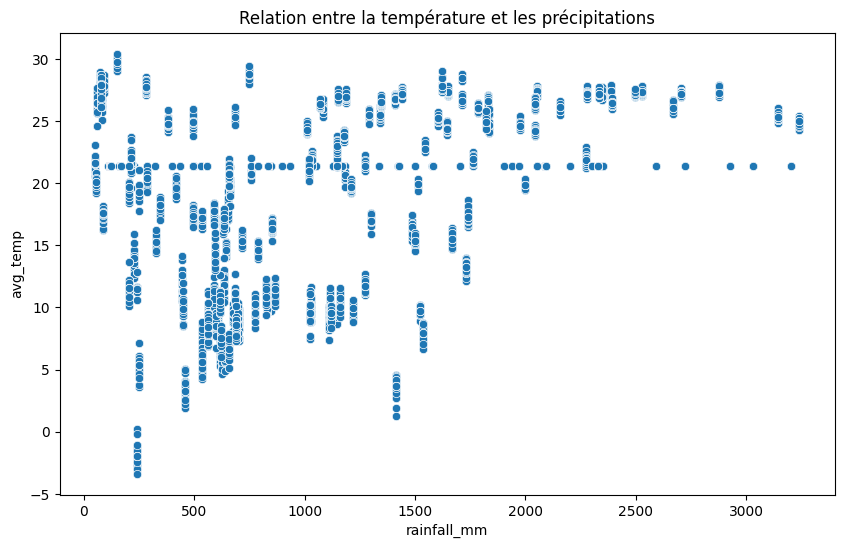

In [104]:
# Relation entre la température et les précipitations
plt.figure(figsize=(10, 6))
sns.scatterplot(x=yield_final['rainfall_mm'], y = yield_final['avg_temp'])
plt.title("Relation entre la température et les précipitations")
plt.show()

- On voit que pour des précipitations élevées, elles sont présentes uniquement avec des températures élevées

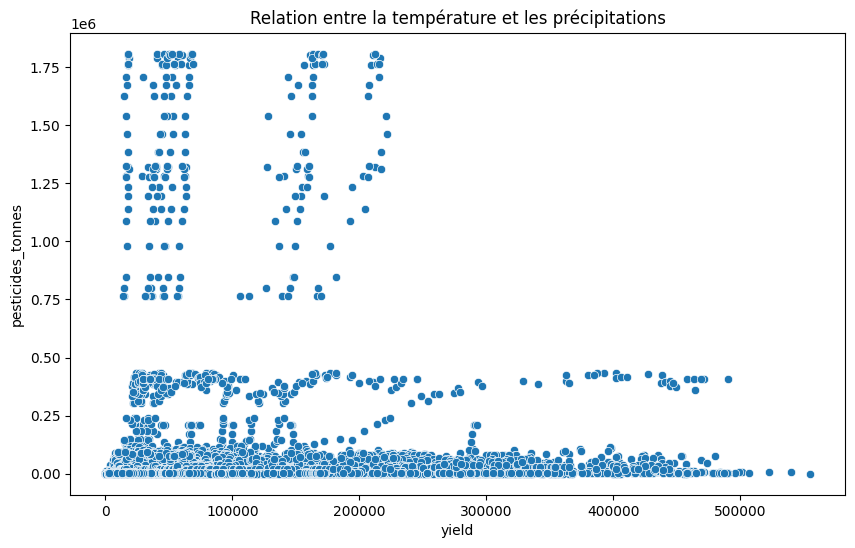

In [105]:
# Relation entre la température et les précipitations
plt.figure(figsize=(10, 6))
sns.scatterplot(x=yield_final['yield'], y = yield_final['pesticides_tonnes'])
plt.title("Relation entre la température et les précipitations")
plt.show()

- Relation très légère entre utilisation des pesticide et rendement

### Pairplot

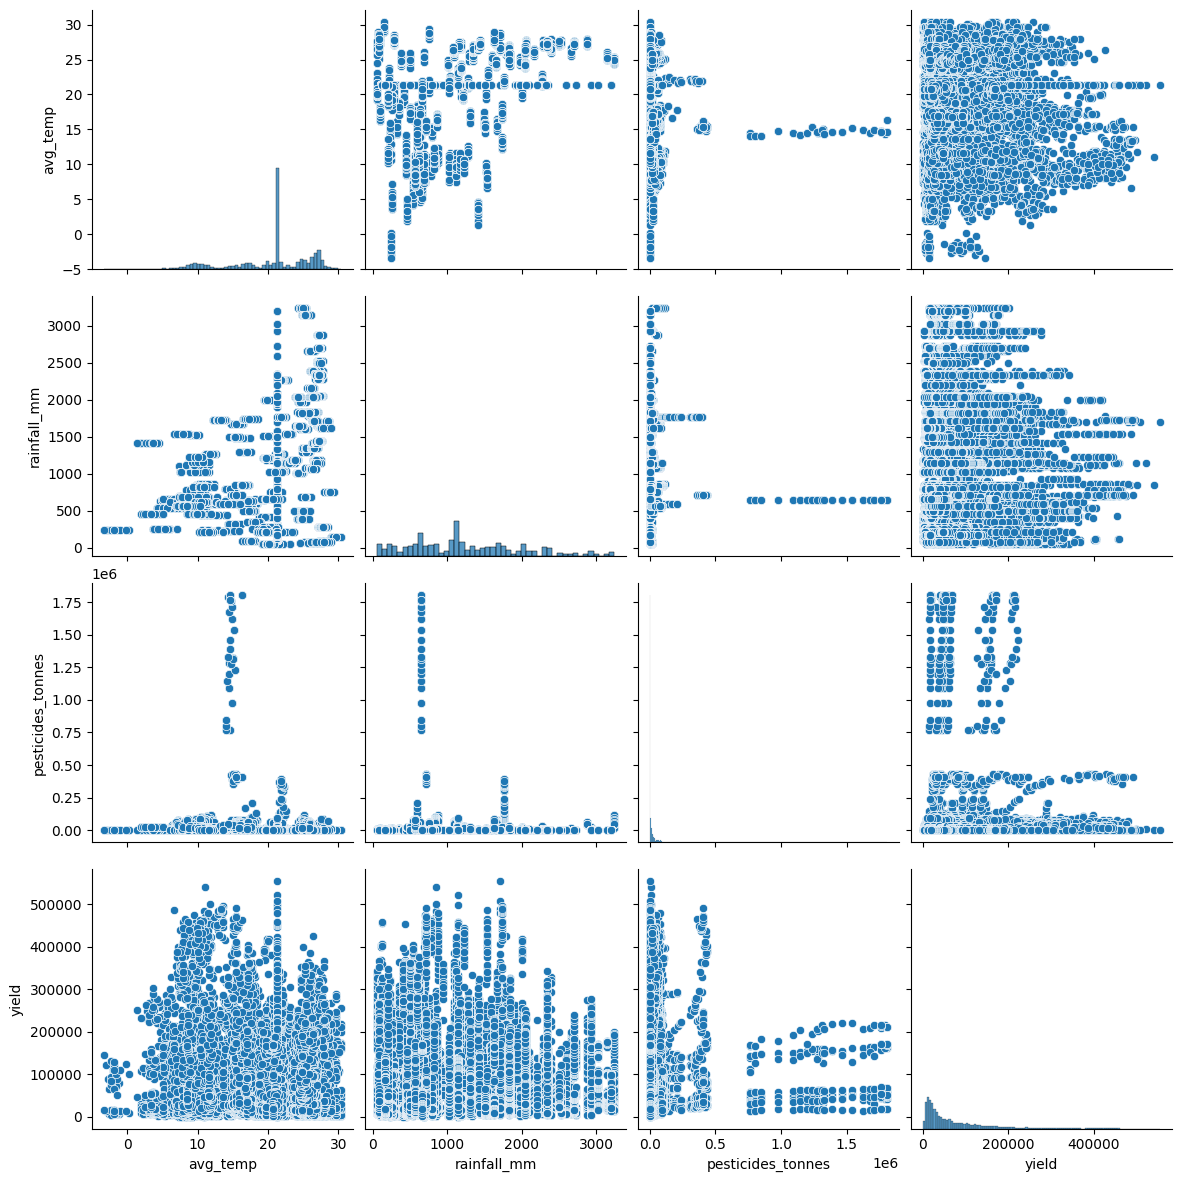

In [106]:
sns.pairplot(yield_final[cols_num], height=3)
plt.show()